# Seminar 04. Image to Voxel

Цель ноутбука: подготовить пары `PNG + STL`, перевести STL в voxel-grid, реализовать attention и обучить три модели для single-view 3D reconstruction.

В ноутбуке используется локальный скрипт `scripts/seminar04_image_to_voxel.py`. Если артефакты уже есть, повторный запуск загрузит готовые чекпойнты и быстро пересчитает метрики; для полного переобучения поставьте `FORCE_TRAIN = True`.

In [1]:
from pathlib import Path
import json
import sys

ROOT = Path.cwd()
if ROOT.name != "seminar_04":
    ROOT = Path("C:/Users/User/Documents/gen-img/designing_neural_network_architectures_2025_02/seminar_04")

sys.path.insert(0, str(ROOT / "scripts"))
from seminar04_image_to_voxel import DATA_DIR, ARTIFACT_DIR, MODEL_SPECS, find_pairs, run_pipeline

DATA_DIR, ARTIFACT_DIR

(WindowsPath('C:/Users/User/Documents/gen-img/designing_neural_network_architectures_2025_02/seminar_04/data_3dmodel'),
 WindowsPath('C:/Users/User/Documents/gen-img/designing_neural_network_architectures_2025_02/seminar_04/artifacts'))

## Подготовка данных

In [2]:
pairs = find_pairs(DATA_DIR)
print(f"Найдено пар PNG/STL: {len(pairs)}")
if pairs:
    print("Пример:", pairs[0][0].name, pairs[0][1].name)

Найдено пар PNG/STL: 561
Пример: part_0000.png part_0000.stl


## Обучение трех моделей

1. `model_1_cnn`: базовый CNN-энкодер и 3D-декодер.
2. `model_2_se_attention`: добавлены SE attention-блоки.
3. `model_3_self_attention`: SE attention + spatial self-attention в bottleneck.

Все модели используют одинаковый train/val/test split и общий Dice+BCE loss.

In [3]:
FORCE_TRAIN = False
EPOCHS = 8

metrics = run_pipeline(
    image_size=64,
    voxel_size=16,
    epochs=EPOCHS,
    batch_size=32,
    force=FORCE_TRAIN,
    rebuild_cache=False,
)

print("Отчет:", metrics["report"])

prepared 75/561 cache items
prepared 150/561 cache items
prepared 225/561 cache items
prepared 300/561 cache items
prepared 375/561 cache items
prepared 450/561 cache items
prepared 525/561 cache items
prepared 561/561 cache items
device: cpu; train/val/test: 403/78/80

training model_1_cnn: Model 1: CNN encoder + 3D decoder



training model_2_se_attention: Model 2: CNN + SE attention



training model_3_self_attention: Model 3: SE + spatial self-attention


Отчет: C:\Users\User\Documents\gen-img\designing_neural_network_architectures_2025_02\seminar_04\reports\seminar_04_report.md


## Метрики

In [4]:
from IPython.display import Markdown, display

rows = [
    "| Модель | Val Dice | Val IoU | Test Dice | Test IoU | Voxel accuracy |",
    "|---|---:|---:|---:|---:|---:|",
]
for key in [spec.key for spec in MODEL_SPECS]:
    row = metrics["models"][key]
    rows.append(
        f"| {key} | {row['best_val']['dice']:.4f} | {row['best_val']['iou']:.4f} | "
        f"{row['test']['dice']:.4f} | {row['test']['iou']:.4f} | {row['test']['voxel_accuracy']:.4f} |"
    )
display(Markdown("\n".join(rows)))

| Модель | Val Dice | Val IoU | Test Dice | Test IoU | Voxel accuracy |
|---|---:|---:|---:|---:|---:|
| model_1_cnn | 0.7801 | 0.6607 | 0.7984 | 0.6812 | 0.9098 |
| model_2_se_attention | 0.7889 | 0.6742 | 0.8071 | 0.6938 | 0.9112 |
| model_3_self_attention | 0.7780 | 0.6594 | 0.7964 | 0.6818 | 0.9052 |

## Графики и примеры предсказаний

training_curves C:\Users\User\Documents\gen-img\designing_neural_network_architectures_2025_02\seminar_04\artifacts\plots\training_curves.png


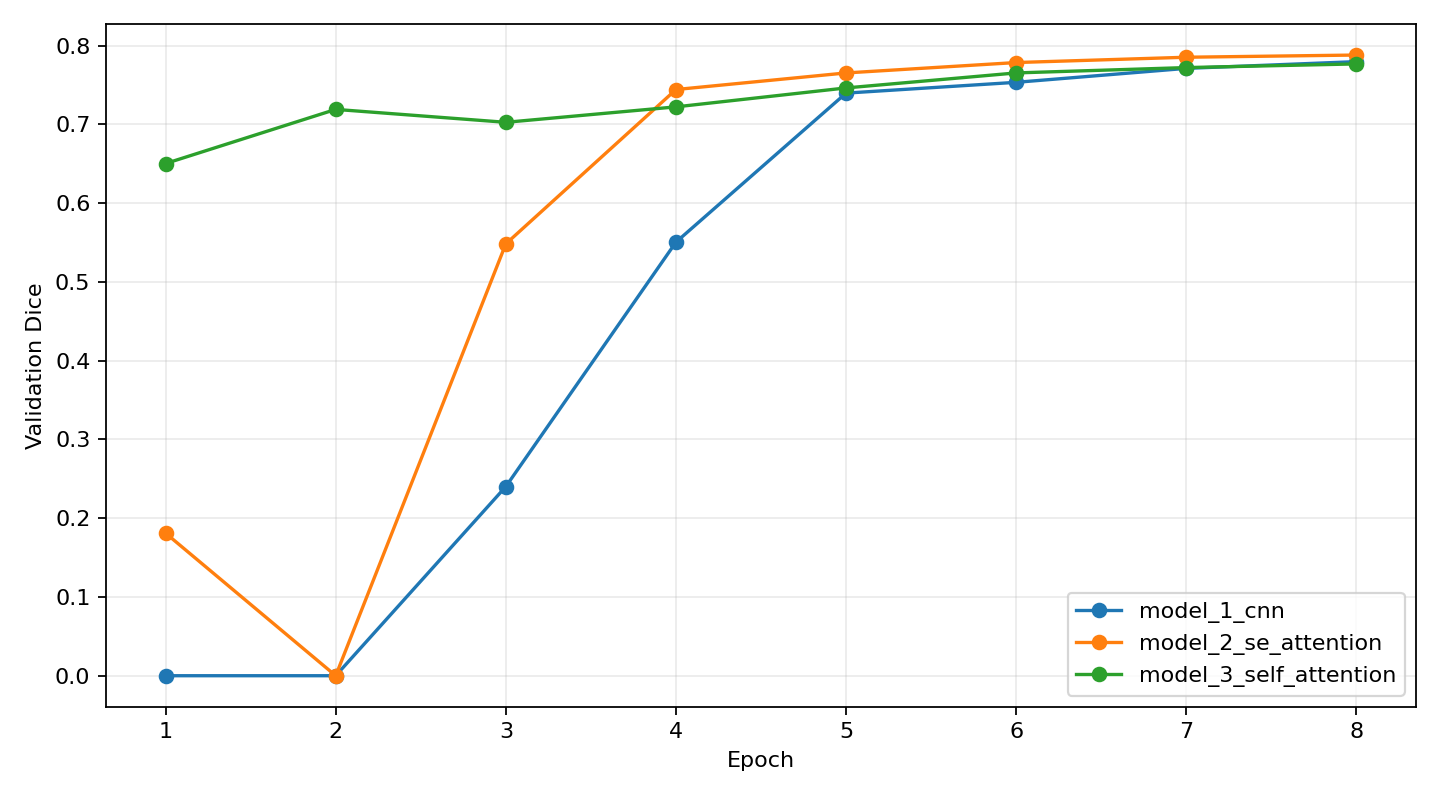

sample_predictions C:\Users\User\Documents\gen-img\designing_neural_network_architectures_2025_02\seminar_04\artifacts\plots\sample_predictions.png


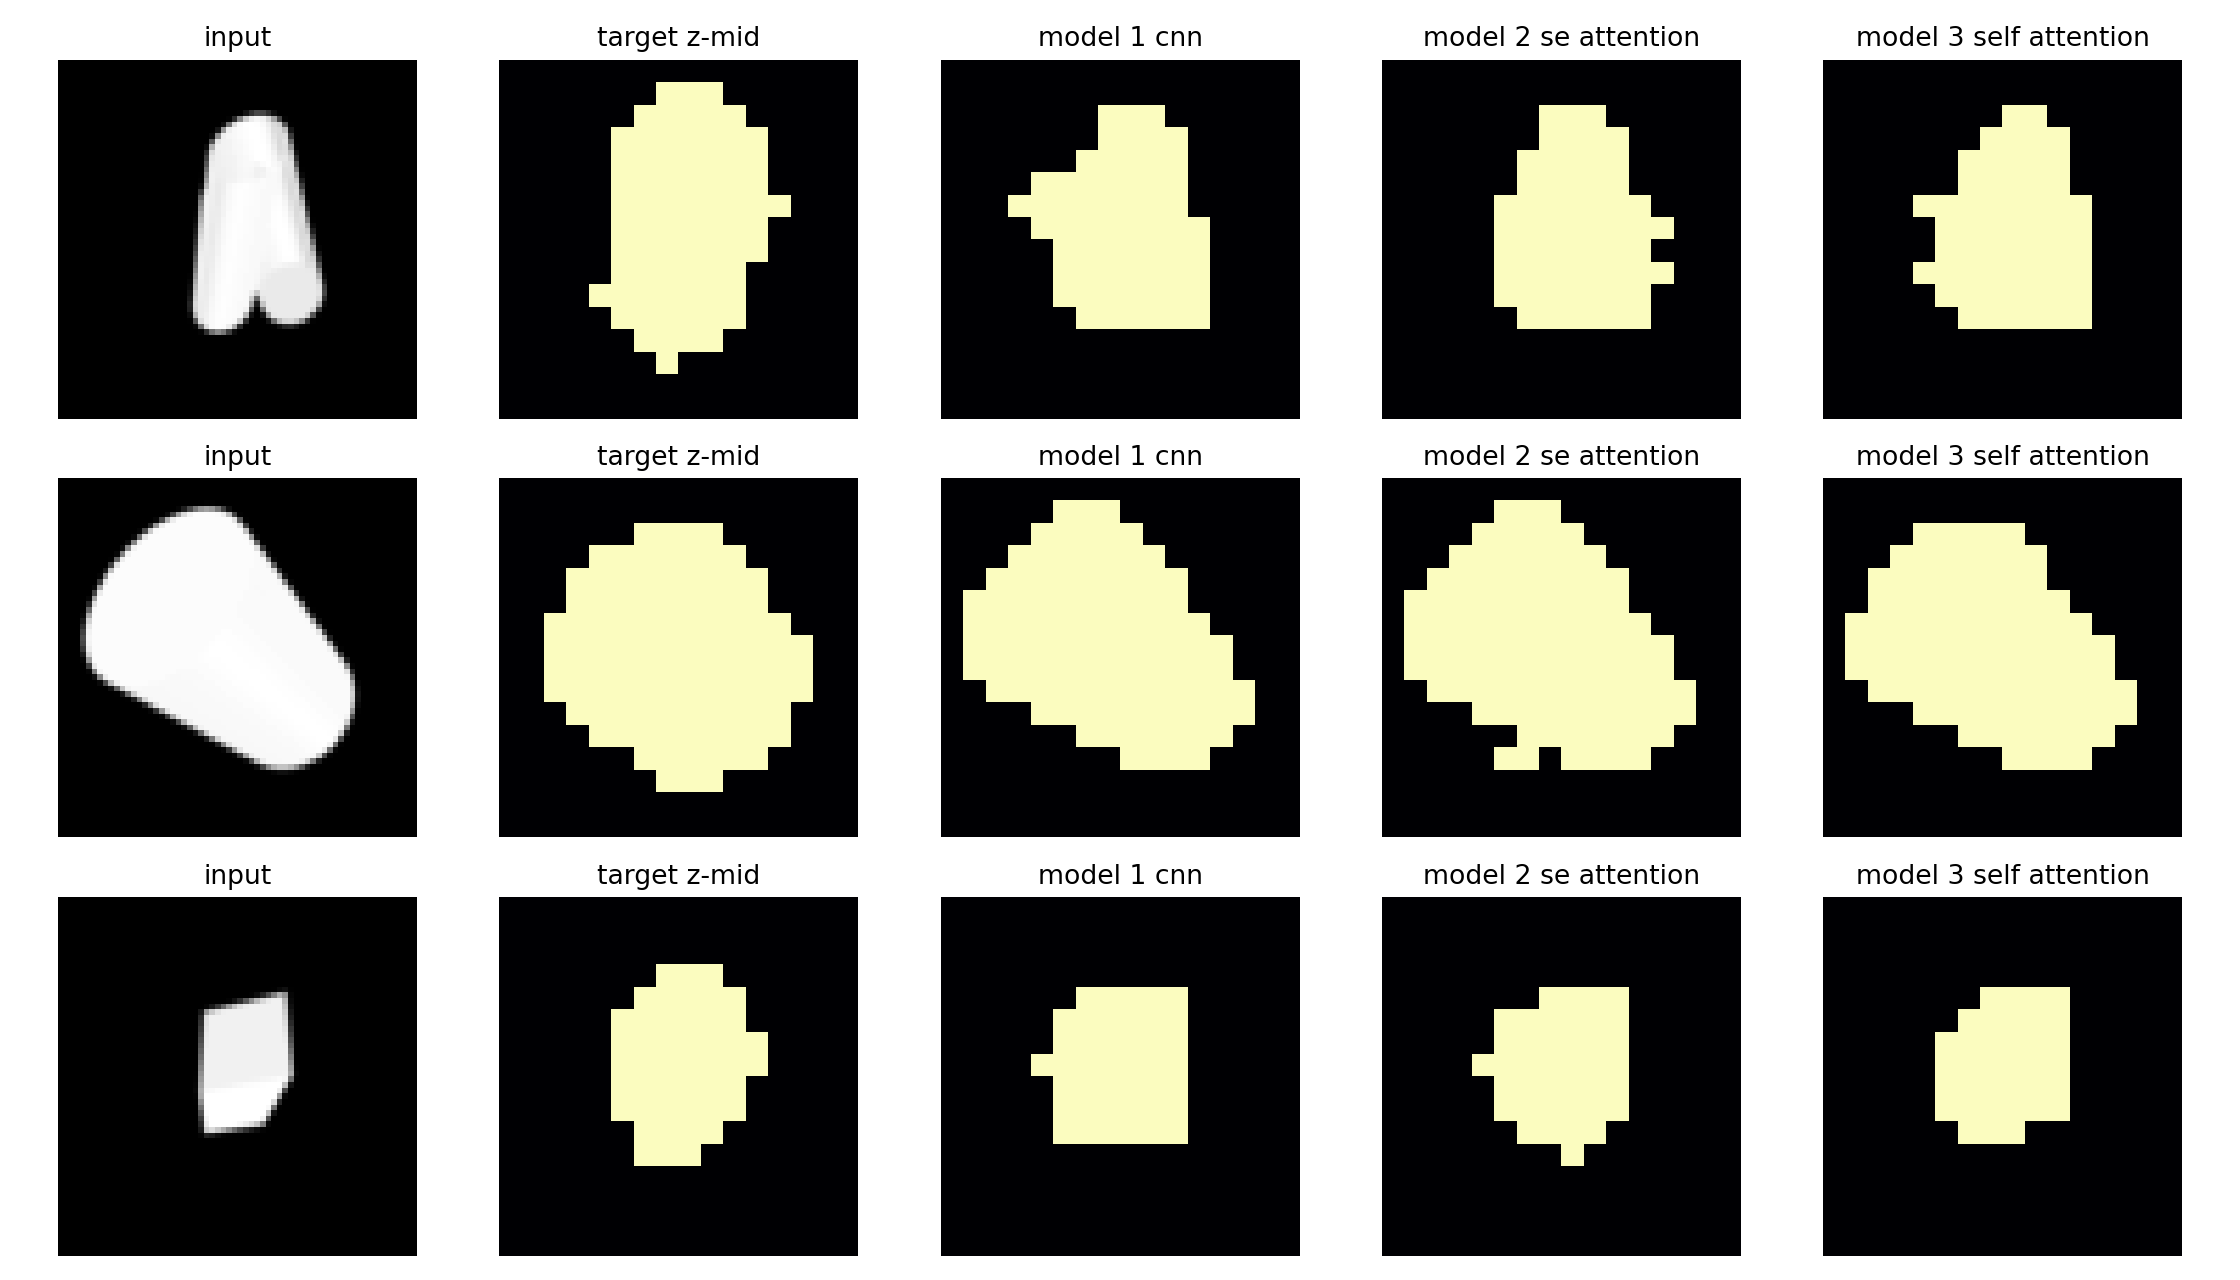

In [5]:
from IPython.display import Image, display

for key in ("training_curves", "sample_predictions"):
    path = metrics.get(key)
    if path and Path(path).exists():
        print(key, path)
        display(Image(filename=path))

## Итог

Данные готовы, attention реализован, три модели обучены и сохранены. Полный отчет лежит в `reports/seminar_04_report.md`.